# Satellite Image Classification


In [1]:
!pip install -q torchinfo torchview peft

In [3]:
import os
import time
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset

import torchvision
from torchvision import transforms, datasets, models
from transformers import CLIPProcessor, CLIPModel

from torchinfo import summary
from torchview import draw_graph
from IPython.display import Image, display

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

from collections import Counter, defaultdict
from tqdm import tqdm

from transformers import ViTForImageClassification
from peft import LoraConfig, get_peft_model

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
def reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")


reproducibility()

Random seed set to 42


## 0: Dataset and Preprocessing


In [6]:
base_transform = transforms.Compose([transforms.ToTensor()])

eurosat_data = datasets.EuroSAT(root="./data", download=True, transform=base_transform)

100%|██████████| 94.3M/94.3M [00:00<00:00, 281MB/s]


In [7]:
num_images = len(eurosat_data)
class_names = eurosat_data.classes
num_classes = len(eurosat_data.classes)
img_shape = eurosat_data[0][0].shape

print(f"Total images: {num_images}")
print(f"Total classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Image shape: {img_shape}")

Total images: 27000
Total classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Image shape: torch.Size([3, 64, 64])


In [8]:
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomChoice(
            [
                transforms.RandomRotation((0, 0)),
                transforms.RandomRotation((90, 90)),
                transforms.RandomRotation((180, 180)),
                transforms.RandomRotation((270, 270)),
            ]
        ),
        transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [9]:
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(eurosat_data):
    class_indices[label].append(idx)

train_full_idx = []
train_10shot_idx = []
train_5shot_idx = []
val_idx = []
test_idx = []

for label, indices in class_indices.items():
    random.shuffle(indices)
    n = len(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_indices = indices[:n_train]
    val_indices = indices[n_train : n_train + n_val]
    test_indices = indices[n_train + n_val :]
    train_full_idx.extend(train_indices)
    val_idx.extend(val_indices)
    test_idx.extend(test_indices)
    train_10shot_idx.extend(train_indices[:10])
    train_5shot_idx.extend(train_indices[:5])

train_full = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_full_idx,
)
train_10shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_10shot_idx,
)
train_5shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_5shot_idx,
)
val_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    val_idx,
)
test_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    test_idx,
)

splits = {
    "Train full": train_full,
    "Train 10-shot": train_10shot,
    "Train 5-shot": train_5shot,
    "Validation": val_set,
    "Test": test_set,
}

for name, split in splits.items():
    labels = [label for _, label in split]
    counts = Counter(labels)
    print(f"\n{name}")
    print(f"Total samples: {len(split)}")
    for cls_id, cls_name in enumerate(class_names):
        print(f"    {cls_name}: {counts.get(cls_id, 0)}")


Train full
Total samples: 18900
    AnnualCrop: 2100
    Forest: 2100
    HerbaceousVegetation: 2100
    Highway: 1750
    Industrial: 1750
    Pasture: 1400
    PermanentCrop: 1750
    Residential: 2100
    River: 1750
    SeaLake: 2100

Train 10-shot
Total samples: 100
    AnnualCrop: 10
    Forest: 10
    HerbaceousVegetation: 10
    Highway: 10
    Industrial: 10
    Pasture: 10
    PermanentCrop: 10
    Residential: 10
    River: 10
    SeaLake: 10

Train 5-shot
Total samples: 50
    AnnualCrop: 5
    Forest: 5
    HerbaceousVegetation: 5
    Highway: 5
    Industrial: 5
    Pasture: 5
    PermanentCrop: 5
    Residential: 5
    River: 5
    SeaLake: 5

Validation
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 375
    Industrial: 375
    Pasture: 300
    PermanentCrop: 375
    Residential: 450
    River: 375
    SeaLake: 450

Test
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 

**Q0.1** Describe in detail the splits you created (size of each split in total and per class). How did you ensure that there is no data leakage between the train, validation and test sets?

In the cell above, I printed all the details about the size of each split in total and per class. To ensure that there is no data leakage between sets, I shuffled indices and cut them into three separate chunks (train:0-70%, val:70:85%, test:85-100%) so that no image appears in more than one chunk. The few-shot sets are strict subsets of the training set, so they never collide with validation or test.

**Q0.2** Which augmentations will you use and why are they considered appropriate and realistic for satellite imagery?

- Random Horizontal & Vertical Flips: Satellite images are top-down views, so by randomly flipping the images we make the model see a slightly different version of the image in the training to prevent it from memorizing the exact original pixels.
- Discrete Random Rotation (0°, 90°, 180°, 270°): Similar to flips, satellite imagery is direction-invariant, so by using 90-degree intervals we preserve the rectangular grid structure without introducing black corners and we assure that the model sees multiple versions of the image in each epoch.
- Random Resized Crop (Scale 0.8-1.0): This augmentation zooms and crops different parts of the image every time. Satellite sensors may capture the same features at different zoom levels and centering. By cropping and resizing, the model learns to recognize features like buildings or trees regardless of their size or position.

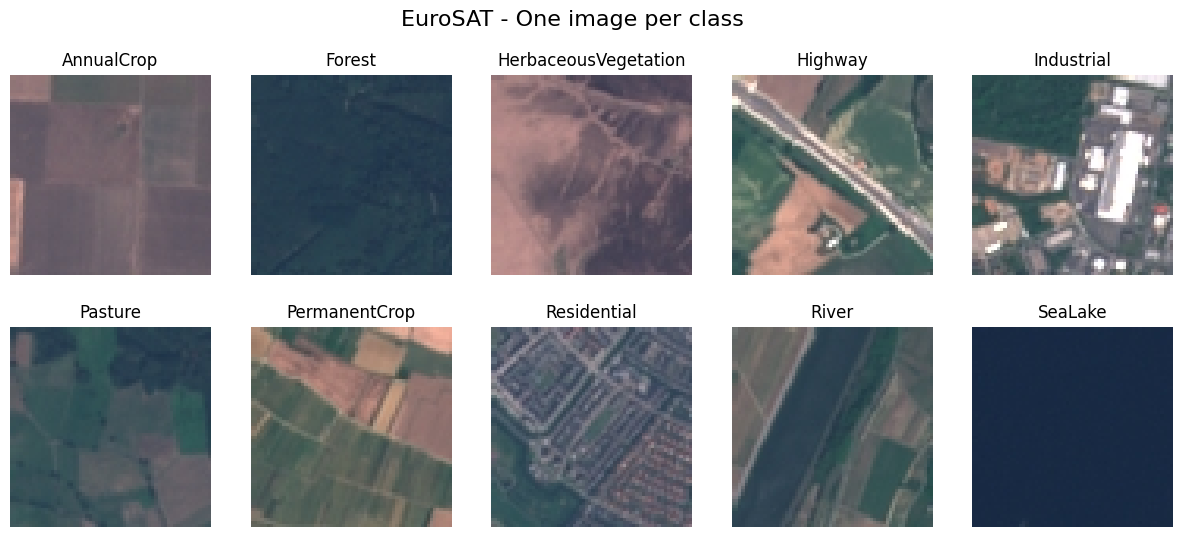

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for cls in range(num_classes):
    for img, label in eurosat_data:
        if label == cls:
            axes[cls].imshow(img.permute(1, 2, 0))
            axes[cls].set_title(class_names[cls])
            axes[cls].axis("off")
            break

plt.suptitle("EuroSAT - One image per class", fontsize=16)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


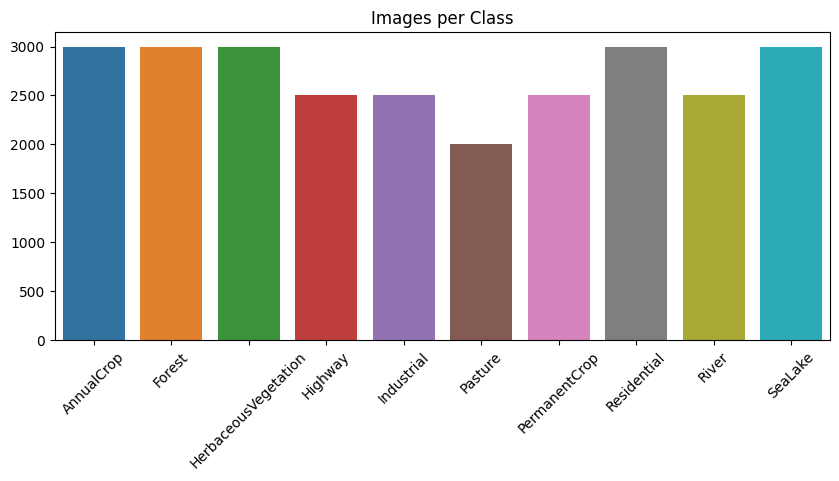

In [10]:
counts = [len(class_indices[c]) for c in range(num_classes)]
plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=counts)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

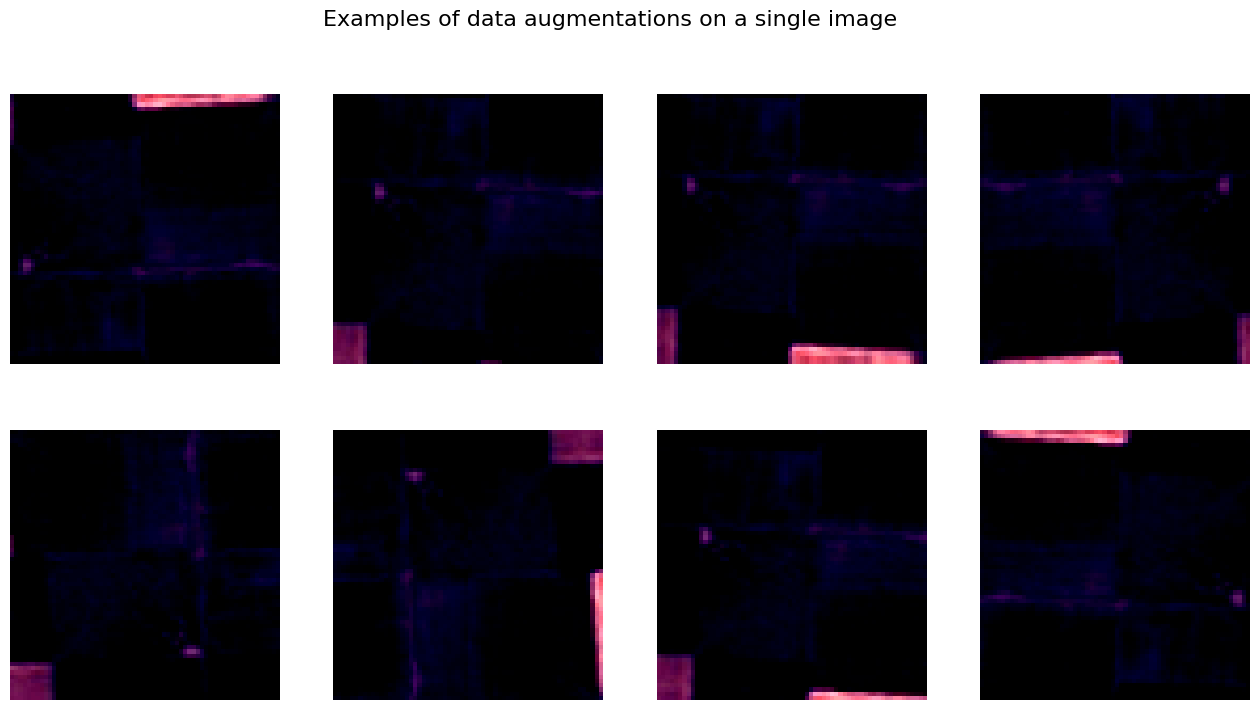

In [11]:
img, _ = eurosat_data[0]
pil_img = transforms.ToPILImage()(img)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    aug_img = train_transform(pil_img)
    axes[i].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
    axes[i].axis("off")

plt.suptitle("Examples of data augmentations on a single image", fontsize=16)
plt.show()

## 1: Baseline and Transfer Learning


### Task 1.1 - Baseline CNN from scratch


In [10]:
def train_per_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    acc = correct / total
    loss = total_loss / total
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    return loss, acc, cm, f1


def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    num_epochs,
    patience=3,
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_per_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(
                f"Early stopping triggered at epoch {epoch+1} "
                f"(best val loss: {best_val_loss:.4f})"
            )
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time
    test_loss, test_acc, test_cm, test_f1 = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Training Time: {training_time / 60:.2f} minutes")

    return {
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "confusion_matrix": test_cm,
        "training_time": training_time,
    }


def plot_train_curves(results, title=""):
    best_epoch = results["best_epoch"]
    epochs = range(1, len(results["train_losses"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, results["train_losses"], label="Train Loss")
    plt.plot(epochs, results["val_losses"], label="Val Loss")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Loss Curves - {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results["train_accs"], label="Train Acc")
    plt.plot(epochs, results["val_accs"], label="Val Acc")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Accuracy Curves - {title}")

    plt.show()


def plot_confusion_matrix(cm, class_names, title=""):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation="vertical")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

In [11]:
batch_size = 32

train_loader = DataLoader(
    train_full, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

In [16]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes).to(device)
summary(model, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           64
│    └─ReLU: 2-3                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-4                    [1, 32, 32, 32]           --
│    └─Conv2d: 2-5                       [1, 64, 32, 32]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 32, 32]           128
│    └─ReLU: 2-7                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-8                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-9                       [1, 128, 16, 16]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 16, 16]          256
│    └─ReLU: 2-11                        [1, 128, 16, 16]          --
│   

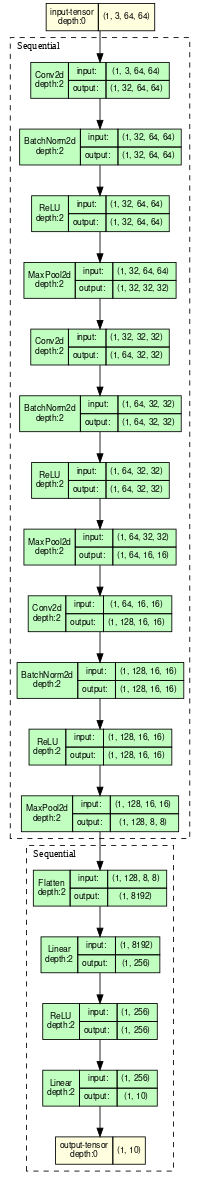

In [17]:
model_graph = draw_graph(
    model, input_size=(1, 3, 64, 64), expand_nested=True, device=device
)
model_graph.visual_graph.render("baseline_cnn", format="png")
display(Image("baseline_cnn.png"))

**Q1.1** Describe the architecture of the baseline model (number and type of layers, activation functions, pooling).

The model is a standard CNN composed of two main parts:

- Feature Extractor (3 Blocks):
    - 3 Convolutional Layers: The network uses 3 Conv2d layers with 3x3 kernels and padding. The number of filters (channels) doubles at each stage: 32 -> 64 -> 128.
    - Normalization & Activation: Each convolution is immediately followed by Batch Normalization and a ReLU activation function.
    - Pooling: A Max Pooling layer with a 2x2 kernel is applied after each block. This reduces the image dimensions from 64×64 down to 8×8.
- Classifier Head (Fully Connected):
    - Flatten: Converts the 3D feature map (128×8×8) into a 1D vector (size 8192).
    - Hidden Layer: A Linear layer maps 8192 inputs to 256 neurons, followed by ReLU.
    - Output Layer: A final Linear layer maps 256 inputs to the 10 output classes.

In [18]:
reproducibility()
cnn = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)

results_cnn = train_model(
    model=cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 1.0011, Train Acc: 0.6466 | Val Loss: 0.6932, Val Acc: 0.7558
Epoch 2/12 | Train Loss: 0.6903, Train Acc: 0.7545 | Val Loss: 0.5766, Val Acc: 0.7990
Epoch 3/12 | Train Loss: 0.5834, Train Acc: 0.7951 | Val Loss: 0.6986, Val Acc: 0.7879
Epoch 4/12 | Train Loss: 0.5140, Train Acc: 0.8188 | Val Loss: 0.4460, Val Acc: 0.8435
Epoch 5/12 | Train Loss: 0.4759, Train Acc: 0.8370 | Val Loss: 0.4616, Val Acc: 0.8375
Epoch 6/12 | Train Loss: 0.4344, Train Acc: 0.8495 | Val Loss: 0.3842, Val Acc: 0.8632
Epoch 7/12 | Train Loss: 0.3865, Train Acc: 0.8662 | Val Loss: 0.4016, Val Acc: 0.8647
Epoch 8/12 | Train Loss: 0.3616, Train Acc: 0.8725 | Val Loss: 0.4892, Val Acc: 0.8430
Epoch 9/12 | Train Loss: 0.3412, Train Acc: 0.8814 | Val Loss: 0.3242, Val Acc: 0.8832
Epoch 10/12 | Train Loss: 0.3166, Train Acc: 0.8917 | Val Loss: 0.2869, Val Acc: 0.9002
Epoch 11/12 | Train Loss: 0.2968, Train Acc: 0.8937 | Val Loss: 0.2774, Val Acc: 0.9044
Epoch 12/12 | Train

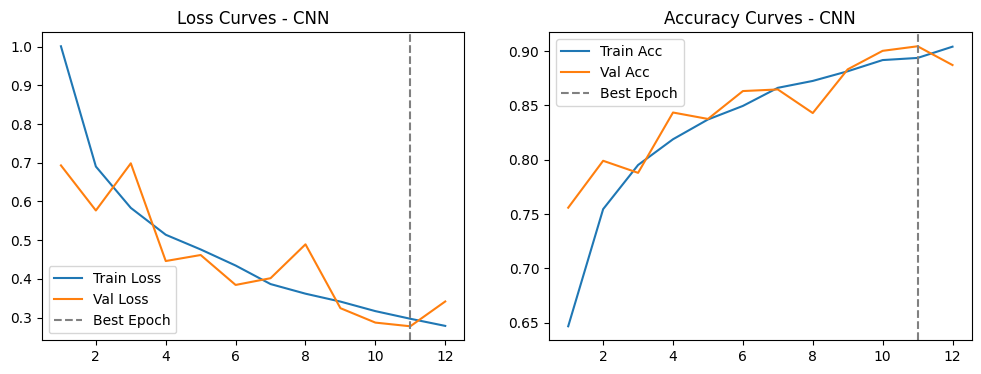

In [19]:
plot_train_curves(results_cnn, "CNN")

**Q1.2** Present training graphs (training and validation curves for loss and/or accuracy)
and report the final test accuracy.

The training curves below show the model learning effectively over 12 epochs. The loss decreases steadily, and accuracy increases, with the best performance on the validation set occurring at Epoch 11.

- Final Test Accuracy: 89.51%

**Q1.3** Report the total training time and the number of parameters of the model.

- Total Training Time: 2.38 minutes

- Total Parameters: 2,193,674

### Task 1.2 - Transfer Learning


In [20]:
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50 = resnet50.to(device)
summary(resnet50, input_size=(1, 3, 64, 64), device=device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s] 


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           9,408
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           --
├─Sequential: 1-5                        [1, 256, 16, 16]          --
│    └─Bottleneck: 2-1                   [1, 256, 16, 16]          --
│    │    └─Conv2d: 3-1                  [1, 64, 16, 16]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-3                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-4                  [1, 64, 16, 16]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-6                    [1, 64, 16, 16]           --
│ 

In [21]:
reproducibility()

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50 = resnet50.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50.parameters(), 1e-3)

results_resnet50 = train_model(
    model=resnet50,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.4556, Train Acc: 0.8615 | Val Loss: 0.2520, Val Acc: 0.9190
Epoch 2/15 | Train Loss: 0.2741, Train Acc: 0.9128 | Val Loss: 0.3661, Val Acc: 0.9000
Epoch 3/15 | Train Loss: 0.2390, Train Acc: 0.9223 | Val Loss: 0.1728, Val Acc: 0.9422
Epoch 4/15 | Train Loss: 0.2081, Train Acc: 0.9332 | Val Loss: 0.1916, Val Acc: 0.9400
Epoch 5/15 | Train Loss: 0.1934, Train Acc: 0.9358 | Val Loss: 0.1737, Val Acc: 0.9442
Epoch 6/15 | Train Loss: 0.1896, Train Acc: 0.9357 | Val Loss: 0.1443, Val Acc: 0.9538
Epoch 7/15 | Train Loss: 0.1707, Train Acc: 0.9440 | Val Loss: 0.2531, Val Acc: 0.9207
Epoch 8/15 | Train Loss: 0.1580, Train Acc: 0.9474 | Val Loss: 0.1458, Val Acc: 0.9526
Epoch 9/15 | Train Loss: 0.1543, Train Acc: 0.9503 | Val Loss: 0.1307, Val Acc: 0.9585
Epoch 10/15 | Train Loss: 0.1482, Train Acc: 0.9498 | Val Loss: 0.1190, Val Acc: 0.9654
Epoch 11/15 | Train Loss: 0.1416, Train Acc: 0.9521 | Val Loss: 0.1532, Val Acc: 0.9531
Epoch 12/15 | Train

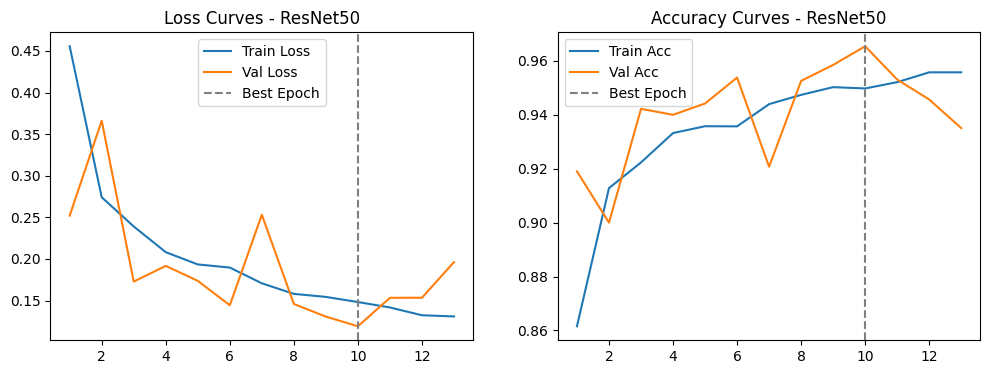

In [22]:
plot_train_curves(results_resnet50, "ResNet50")

In [23]:
resnet50_frozen = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in resnet50_frozen.parameters():
    param.requires_grad = False
resnet50_frozen.fc = nn.Linear(resnet50_frozen.fc.in_features, num_classes)
resnet50_frozen = resnet50_frozen.to(device)
summary(resnet50_frozen, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           (128)
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           --
├─Sequential: 1-5                        [1, 256, 16, 16]          --
│    └─Bottleneck: 2-1                   [1, 256, 16, 16]          --
│    │    └─Conv2d: 3-1                  [1, 64, 16, 16]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 16, 16]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-4                  [1, 64, 16, 16]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 16, 16]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 16, 16]    

In [24]:
reproducibility()

resnet50_frozen = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in resnet50_frozen.parameters():
    param.requires_grad = False
resnet50_frozen.fc = nn.Linear(resnet50_frozen.fc.in_features, num_classes)
resnet50_frozen = resnet50_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50_frozen.parameters(), 1e-3)

results_resnet50_frozen = train_model(
    model=resnet50_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 0.8712, Train Acc: 0.7586 | Val Loss: 0.4905, Val Acc: 0.8538
Epoch 2/12 | Train Loss: 0.5695, Train Acc: 0.8269 | Val Loss: 0.4277, Val Acc: 0.8649
Epoch 3/12 | Train Loss: 0.5231, Train Acc: 0.8369 | Val Loss: 0.4049, Val Acc: 0.8681
Epoch 4/12 | Train Loss: 0.5048, Train Acc: 0.8367 | Val Loss: 0.4056, Val Acc: 0.8694
Epoch 5/12 | Train Loss: 0.4841, Train Acc: 0.8425 | Val Loss: 0.3789, Val Acc: 0.8741
Epoch 6/12 | Train Loss: 0.4863, Train Acc: 0.8414 | Val Loss: 0.3747, Val Acc: 0.8753
Epoch 7/12 | Train Loss: 0.4593, Train Acc: 0.8525 | Val Loss: 0.3808, Val Acc: 0.8802
Epoch 8/12 | Train Loss: 0.4718, Train Acc: 0.8478 | Val Loss: 0.3848, Val Acc: 0.8770
Epoch 9/12 | Train Loss: 0.4666, Train Acc: 0.8512 | Val Loss: 0.3946, Val Acc: 0.8768
Early stopping triggered at epoch 9 (best val loss: 0.3747)
Test Accuracy: 86.86%
Training Time: 2.10 minutes


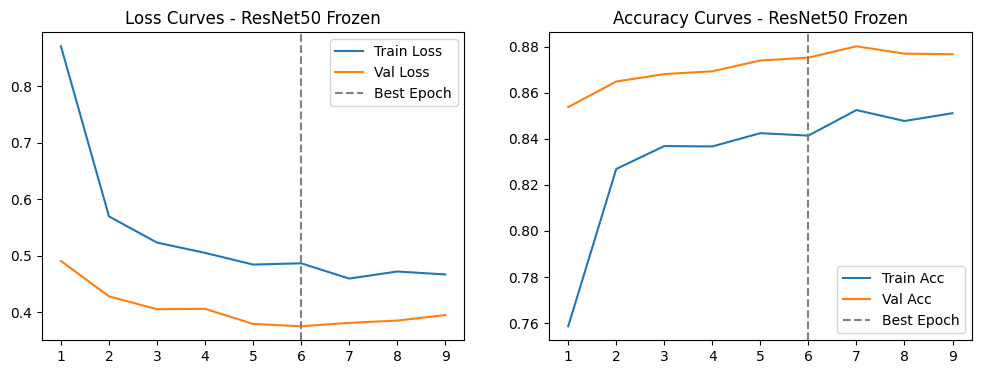

In [25]:
plot_train_curves(results_resnet50_frozen, "ResNet50 Frozen")

In [26]:
efficientnetb0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0.classifier[1].in_features
efficientnetb0.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0 = efficientnetb0.to(device)
summary(efficientnetb0, input_size=(1, 3, 64, 64), device=device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 151MB/s]


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 10]                   --
├─Sequential: 1-1                                       [1, 1280, 2, 2]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                                 [1, 32, 32, 32]           864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 32, 32]           64
│    │    └─SiLU: 3-3                                   [1, 32, 32, 32]           --
│    └─Sequential: 2-2                                  [1, 16, 32, 32]           --
│    │    └─MBConv: 3-4                                 [1, 16, 32, 32]           1,448
│    └─Sequential: 2-3                                  [1, 24, 16, 16]           --
│    │    └─MBConv: 3-5                                 [1, 24, 16, 16]           6,004
│    │    └─MBConv: 3-6                              

In [27]:
reproducibility()

efficientnetb0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0.classifier[1].in_features
efficientnetb0.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0 = efficientnetb0.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0.parameters(), 1e-3)

results_efficientnetb0 = train_model(
    model=efficientnetb0,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.4629, Train Acc: 0.8614 | Val Loss: 0.2121, Val Acc: 0.9351
Epoch 2/15 | Train Loss: 0.2394, Train Acc: 0.9239 | Val Loss: 0.1289, Val Acc: 0.9553
Epoch 3/15 | Train Loss: 0.1821, Train Acc: 0.9414 | Val Loss: 0.2211, Val Acc: 0.9210
Epoch 4/15 | Train Loss: 0.1620, Train Acc: 0.9485 | Val Loss: 0.1242, Val Acc: 0.9630
Epoch 5/15 | Train Loss: 0.1468, Train Acc: 0.9514 | Val Loss: 0.0867, Val Acc: 0.9723
Epoch 6/15 | Train Loss: 0.1397, Train Acc: 0.9548 | Val Loss: 0.1197, Val Acc: 0.9622
Epoch 7/15 | Train Loss: 0.1323, Train Acc: 0.9573 | Val Loss: 0.1005, Val Acc: 0.9686
Epoch 8/15 | Train Loss: 0.1308, Train Acc: 0.9570 | Val Loss: 0.1026, Val Acc: 0.9686
Early stopping triggered at epoch 8 (best val loss: 0.0867)
Test Accuracy: 96.37%
Training Time: 3.16 minutes


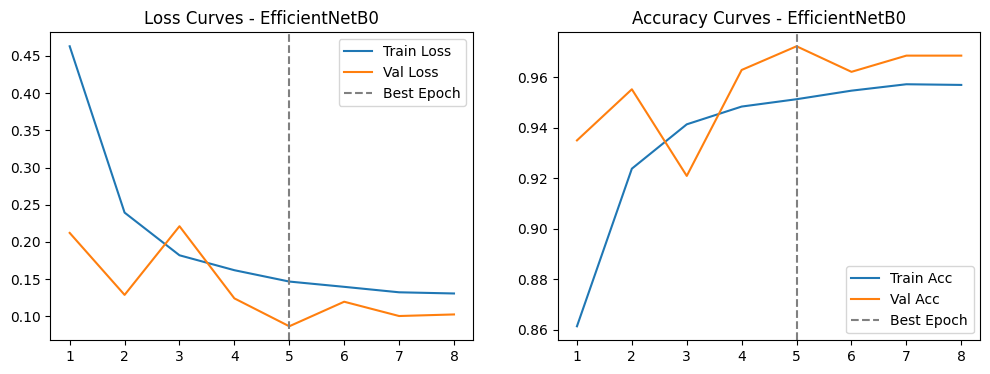

In [28]:
plot_train_curves(results_efficientnetb0, "EfficientNetB0")

In [29]:
efficientnetb0_frozen = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
for param in efficientnetb0_frozen.parameters():
    param.requires_grad = False
in_features = efficientnetb0_frozen.classifier[1].in_features
efficientnetb0_frozen.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_frozen = efficientnetb0_frozen.to(device)
summary(efficientnetb0_frozen, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 10]                   --
├─Sequential: 1-1                                       [1, 1280, 2, 2]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                                 [1, 32, 32, 32]           (864)
│    │    └─BatchNorm2d: 3-2                            [1, 32, 32, 32]           (64)
│    │    └─SiLU: 3-3                                   [1, 32, 32, 32]           --
│    └─Sequential: 2-2                                  [1, 16, 32, 32]           --
│    │    └─MBConv: 3-4                                 [1, 16, 32, 32]           (1,448)
│    └─Sequential: 2-3                                  [1, 24, 16, 16]           --
│    │    └─MBConv: 3-5                                 [1, 24, 16, 16]           (6,004)
│    │    └─MBConv: 3-6                      

In [23]:
reproducibility()

efficientnetb0_frozen = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
for param in efficientnetb0_frozen.parameters():
    param.requires_grad = False
in_features = efficientnetb0_frozen.classifier[1].in_features
efficientnetb0_frozen.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_frozen = efficientnetb0_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_frozen.parameters(), 1e-3)

results_efficientnetb0_frozen = train_model(
    model=efficientnetb0_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s] 


Epoch 1/15 | Train Loss: 0.8824, Train Acc: 0.7184 | Val Loss: 0.8649, Val Acc: 0.7620
Epoch 2/15 | Train Loss: 0.7259, Train Acc: 0.7575 | Val Loss: 0.7706, Val Acc: 0.7751
Epoch 3/15 | Train Loss: 0.7173, Train Acc: 0.7596 | Val Loss: 0.6816, Val Acc: 0.7689
Epoch 4/15 | Train Loss: 0.7231, Train Acc: 0.7598 | Val Loss: 0.6669, Val Acc: 0.7746
Epoch 5/15 | Train Loss: 0.7086, Train Acc: 0.7625 | Val Loss: 0.6943, Val Acc: 0.7862
Epoch 6/15 | Train Loss: 0.7055, Train Acc: 0.7644 | Val Loss: 0.6677, Val Acc: 0.7815
Epoch 7/15 | Train Loss: 0.7119, Train Acc: 0.7616 | Val Loss: 0.7187, Val Acc: 0.7709
Early stopping triggered at epoch 7 (best val loss: 0.6669)
Test Accuracy: 76.79%
Training Time: 1.78 minutes


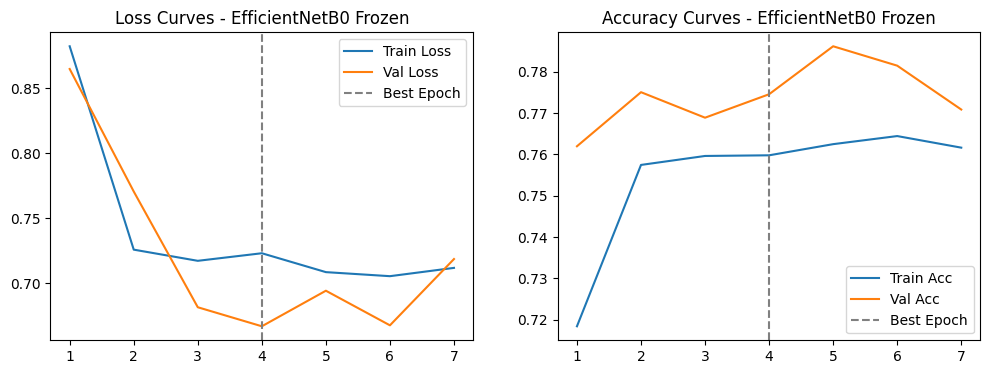

In [24]:
plot_train_curves(results_efficientnetb0_frozen, "EfficientNetB0 Frozen")

In [30]:
def train_per_epoch_vit(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=x)
        logits = outputs.logits
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate_vit(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(pixel_values=x)
            logits = outputs.logits
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    acc = correct / total
    loss = total_loss / total
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    return loss, acc, cm, f1


def train_model_vit(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    num_epochs,
    patience=3,
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_per_epoch_vit(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, _, _ = evaluate_vit(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(
                f"Early stopping triggered at epoch {epoch+1} "
                f"(best val loss: {best_val_loss:.4f})"
            )
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time
    test_loss, test_acc, test_cm, test_f1 = evaluate_vit(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Training Time: {training_time / 60:.2f} minutes")

    return {
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "confusion_matrix": test_cm,
        "training_time": training_time,
    }


def plot_train_curves(results, title=""):
    best_epoch = results["best_epoch"]
    epochs = range(1, len(results["train_losses"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, results["train_losses"], label="Train Loss")
    plt.plot(epochs, results["val_losses"], label="Val Loss")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Loss Curves - {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results["train_accs"], label="Train Acc")
    plt.plot(epochs, results["val_accs"], label="Val Acc")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Accuracy Curves - {title}")

    plt.show()


def plot_confusion_matrix(cm, class_names, title=""):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation="vertical")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

In [13]:
train_transform_vit = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomChoice(
            [
                transforms.RandomRotation((0, 0)),
                transforms.RandomRotation((90, 90)),
                transforms.RandomRotation((180, 180)),
                transforms.RandomRotation((270, 270)),
            ]
        ),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform_vit = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_full_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_full_idx,
)
val_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    val_idx,
)
test_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    test_idx,
)

batch_size_vit = 32

train_loader_vit = DataLoader(
    train_full_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)
val_loader_vit = DataLoader(
    val_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=2
)
test_loader_vit = DataLoader(
    test_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=2
)

In [30]:
vit = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
vit = vit.to(device)
summary(vit, input_size=(1, 3, 224, 224), device=device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                  Output Shape              Param #
ViTForImageClassification                               [1, 10]                   --
├─ViTModel: 1-1                                         [1, 197, 768]             --
│    └─ViTEmbeddings: 2-1                               [1, 197, 768]             152,064
│    │    └─ViTPatchEmbeddings: 3-1                     [1, 196, 768]             590,592
│    │    └─Dropout: 3-2                                [1, 197, 768]             --
│    └─ViTEncoder: 2-2                                  [1, 197, 768]             --
│    │    └─ModuleList: 3-3                             --                        85,054,464
│    └─LayerNorm: 2-3                                   [1, 197, 768]             1,536
├─Linear: 1-2                                           [1, 10]                   7,690
Total params: 85,806,346
Trainable params: 85,806,346
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 200.82
I

In [33]:
reproducibility()

vit = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
vit = vit.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit.parameters(), lr=1e-4, weight_decay=0.01)

results_vit = train_model_vit(
    model=vit,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=10,
)

Random seed set to 42


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10 | Train Loss: 0.1625, Train Acc: 0.9494 | Val Loss: 0.1033, Val Acc: 0.9617
Epoch 2/10 | Train Loss: 0.0689, Train Acc: 0.9776 | Val Loss: 0.0626, Val Acc: 0.9810
Epoch 3/10 | Train Loss: 0.0574, Train Acc: 0.9816 | Val Loss: 0.0728, Val Acc: 0.9785
Epoch 4/10 | Train Loss: 0.0481, Train Acc: 0.9848 | Val Loss: 0.0519, Val Acc: 0.9832
Epoch 5/10 | Train Loss: 0.0419, Train Acc: 0.9866 | Val Loss: 0.0802, Val Acc: 0.9790
Epoch 6/10 | Train Loss: 0.0396, Train Acc: 0.9866 | Val Loss: 0.0599, Val Acc: 0.9807
Epoch 7/10 | Train Loss: 0.0342, Train Acc: 0.9887 | Val Loss: 0.0691, Val Acc: 0.9785
Early stopping triggered at epoch 7 (best val loss: 0.0519)
Test Accuracy: 98.47%
Training Time: 76.52 minutes


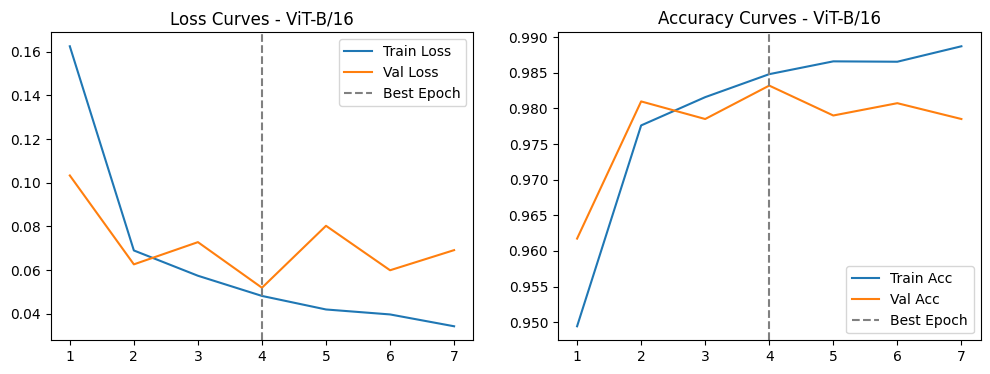

In [34]:
plot_train_curves(results_vit, "ViT-B/16")

In [14]:
vit_frozen = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
for name, param in vit_frozen.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False
vit_frozen = vit_frozen.to(device)
summary(vit_frozen, input_size=(1, 3, 224, 224), device=device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                  Output Shape              Param #
ViTForImageClassification                               [1, 10]                   --
├─ViTModel: 1-1                                         [1, 197, 768]             --
│    └─ViTEmbeddings: 2-1                               [1, 197, 768]             152,064
│    │    └─ViTPatchEmbeddings: 3-1                     [1, 196, 768]             (590,592)
│    │    └─Dropout: 3-2                                [1, 197, 768]             --
│    └─ViTEncoder: 2-2                                  [1, 197, 768]             --
│    │    └─ModuleList: 3-3                             --                        (85,054,464)
│    └─LayerNorm: 2-3                                   [1, 197, 768]             (1,536)
├─Linear: 1-2                                           [1, 10]                   7,690
Total params: 85,806,346
Trainable params: 7,690
Non-trainable params: 85,798,656
Total mult-adds (Units.MEGABYTES)

In [15]:
reproducibility()

vit_frozen = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
for name, param in vit_frozen.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False
vit_frozen = vit_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit_frozen.parameters(), lr=1e-3)

results_vit_frozen = train_model_vit(
    model=vit_frozen,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15 | Train Loss: 0.3382, Train Acc: 0.9023 | Val Loss: 0.2059, Val Acc: 0.9314
Epoch 2/15 | Train Loss: 0.1682, Train Acc: 0.9461 | Val Loss: 0.1569, Val Acc: 0.9494
Epoch 3/15 | Train Loss: 0.1409, Train Acc: 0.9544 | Val Loss: 0.1471, Val Acc: 0.9511
Epoch 4/15 | Train Loss: 0.1238, Train Acc: 0.9590 | Val Loss: 0.1422, Val Acc: 0.9536
Epoch 5/15 | Train Loss: 0.1196, Train Acc: 0.9599 | Val Loss: 0.1293, Val Acc: 0.9565
Epoch 6/15 | Train Loss: 0.1118, Train Acc: 0.9619 | Val Loss: 0.1263, Val Acc: 0.9568
Epoch 7/15 | Train Loss: 0.1065, Train Acc: 0.9647 | Val Loss: 0.1317, Val Acc: 0.9521
Epoch 8/15 | Train Loss: 0.1031, Train Acc: 0.9641 | Val Loss: 0.1414, Val Acc: 0.9486
Epoch 9/15 | Train Loss: 0.0998, Train Acc: 0.9672 | Val Loss: 0.1247, Val Acc: 0.9551
Epoch 10/15 | Train Loss: 0.0957, Train Acc: 0.9666 | Val Loss: 0.1313, Val Acc: 0.9563
Epoch 11/15 | Train Loss: 0.0935, Train Acc: 0.9684 | Val Loss: 0.1230, Val Acc: 0.9585
Epoch 12/15 | Train Loss: 0.0878, Train A

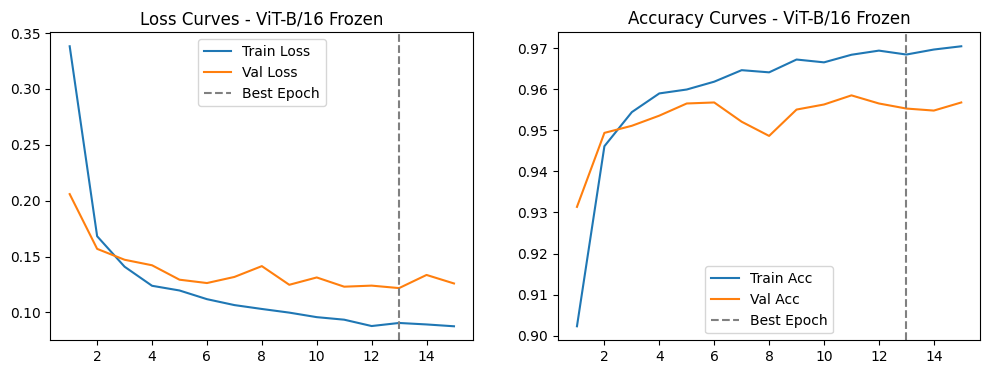

In [16]:
plot_train_curves(results_vit_frozen, "ViT-B/16 Frozen")

**Q1.4**

| Model | Strategy | Test Accuracy (%) | Training Time (minutes) | Trainable Parameters |
| :--- | :--- | :--- | :--- | :--- |
| **ResNet50** | Full FT | 96.12 | 8.33 | 23,528,522 |
| **ResNet50** | Frozen | 86.86 | 2.10 | 20,490 |
| **EfficientNet-B0** | Full FT | 96.37 | 3.16 | 4,020,358 |
| **EfficientNet-B0** | Frozen | 76.79 | 1.78 | 12,810 |
| **ViT-B/16** | Full FT | 98.47 | 76.52 | 85,806,346 |
| **ViT-B/16** | Frozen | 95.80 | 76.83 | 7,690 |

**Q1.5** Which model and strategy (full fine-tuning or frozen) performed best and why do you think this happened?

ViT-B/16 with full fine-tuning perfomed the best and achieved the highest test accuracy (98.47%). The first reason this happened is that transformers use self-attention, allowing the model to look at the entire image at once (global context) and helping it in distinguishing more complex features that separate the 10 classes. The second reason has to do with the capacity of the model (85m parameters), enabling it to store significantly more complex patters patterns than the CNN's. The third and final reason is that the full fine-tuning helped the model adjust its deep feature extractors specifically for the satellite imagery instead of relying on the pre-trained weights of ImageNet photos.

**Q1.6** How did backbone freezing affect training time and final performance?

- Training Time:
    - CNNs(ResNet/EfficientNet): Freezing drastically reduced training time (3-4x faster) cause the gradient calculation (backward pass) was skipped for most layers.
    - ViT: Freezing did reduce the per epoch time from ~11 minutes/epoch on full fine-tuned to ~5 minutes/epoch. The total is the same because the frozen ViT ran for more than double the epochs (15 vs 7) to ensure that it achieved the best performance and generalization without overfitting.
- Final Performance:
    - CNNs(ResNet/EfficientNet): Freezing caused a massive drop in performance (EfficientNet -20%, ResNet -10%) and that happened because CNN features from ImageNet don't transfer perfectly to satellite data without full fine-tuning.
    - ViT: Freezing had a minimal drop in performance (~2%). This proves that ViT learns more features from ImageNet that can be transfered and work well on satellite data even without full fine-tuning.

**Q1.7** Compare Vision Transformer's behavior qualitatively with CNN based models in EuroSAT. Are there any differences in performance, training time, or data efficiency?

- Performance: ViT is superior, beating both CNN's by ~2%. Also frozen ViT achieved about the same performance as the full fine-tuned CNNs.
- Training Time: ViT is extremely heavy. Even the faster frozen ViT was far slower than the slowest full ResNet50 (76 mins vs 8 mins). The main reasons this happens is because the ViT requires resizing images to 224 x 224, increasing pixel counte by 12x, and has 4x more parameters than ResNet50.
- Data Efficiency: ViT is more data-efficient in terms of transferability. Its frozen embeddings are high-quality (95.8% accuracy), whereas frozen CNN embeddings struggle (76-86%).

### Task 1.3 – Transfer Learning in Few-Shot scenarios


In [23]:
batch_size = 32

train_10shot_loader = DataLoader(
    train_10shot, batch_size=batch_size, shuffle=True, num_workers=2
)

train_5shot_loader = DataLoader(
    train_5shot, batch_size=batch_size, shuffle=True, num_workers=2
)

In [18]:
batch_size_vit = 32

train_10shot_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_10shot_idx,
)

train_loader_vit_10shot = DataLoader(
    train_10shot_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)

train_5shot_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_5shot_idx,
)

train_loader_vit_5shot = DataLoader(
    train_5shot_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)

In [19]:
reproducibility()

vit_10shot = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
vit_10shot = vit_10shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit_10shot.parameters(), lr=1e-4, weight_decay=0.01)

results_vit_10shot = train_model_vit(
    model=vit_10shot,
    train_loader=train_loader_vit_10shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15 | Train Loss: 2.1781, Train Acc: 0.1900 | Val Loss: 1.5342, Val Acc: 0.6244
Epoch 2/15 | Train Loss: 1.1861, Train Acc: 0.8000 | Val Loss: 1.1433, Val Acc: 0.6995
Epoch 3/15 | Train Loss: 0.6682, Train Acc: 0.9400 | Val Loss: 0.8738, Val Acc: 0.7637
Epoch 4/15 | Train Loss: 0.3726, Train Acc: 0.9900 | Val Loss: 0.6724, Val Acc: 0.8148
Epoch 5/15 | Train Loss: 0.2334, Train Acc: 0.9700 | Val Loss: 0.5669, Val Acc: 0.8244
Epoch 6/15 | Train Loss: 0.1221, Train Acc: 1.0000 | Val Loss: 0.4737, Val Acc: 0.8548
Epoch 7/15 | Train Loss: 0.0799, Train Acc: 1.0000 | Val Loss: 0.4239, Val Acc: 0.8728
Epoch 8/15 | Train Loss: 0.0457, Train Acc: 1.0000 | Val Loss: 0.4142, Val Acc: 0.8706
Epoch 9/15 | Train Loss: 0.0319, Train Acc: 1.0000 | Val Loss: 0.4319, Val Acc: 0.8615
Epoch 10/15 | Train Loss: 0.0254, Train Acc: 1.0000 | Val Loss: 0.4541, Val Acc: 0.8543
Epoch 11/15 | Train Loss: 0.0222, Train Acc: 1.0000 | Val Loss: 0.4467, Val Acc: 0.8565
Early stopping triggered at epoch 11 (bes

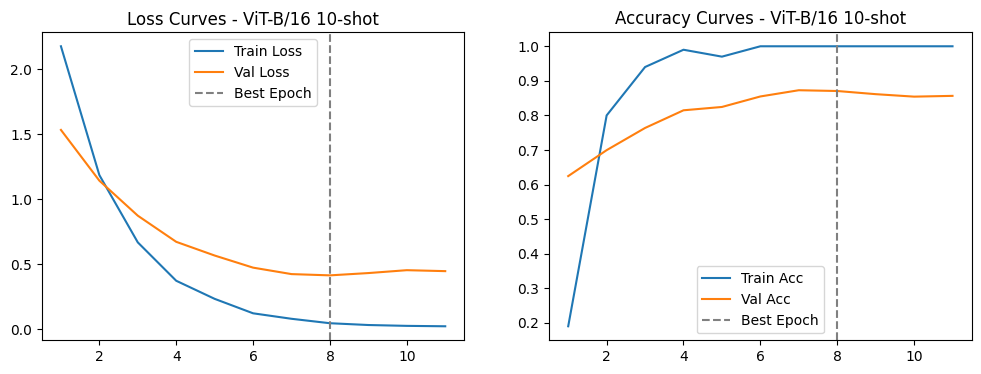

In [20]:
plot_train_curves(results_vit_10shot, "ViT-B/16 10-shot")

In [21]:
reproducibility()

vit_5shot = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
vit_5shot = vit_5shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit_5shot.parameters(), lr=1e-4, weight_decay=0.01)

results_vit_5shot = train_model_vit(
    model=vit_5shot,
    train_loader=train_loader_vit_5shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15 | Train Loss: 2.3163, Train Acc: 0.2000 | Val Loss: 1.9110, Val Acc: 0.4452
Epoch 2/15 | Train Loss: 1.4731, Train Acc: 0.7800 | Val Loss: 1.5679, Val Acc: 0.6079
Epoch 3/15 | Train Loss: 0.9330, Train Acc: 0.9400 | Val Loss: 1.2473, Val Acc: 0.6830
Epoch 4/15 | Train Loss: 0.6034, Train Acc: 0.9800 | Val Loss: 1.0728, Val Acc: 0.7202
Epoch 5/15 | Train Loss: 0.3708, Train Acc: 0.9800 | Val Loss: 0.8635, Val Acc: 0.7926
Epoch 6/15 | Train Loss: 0.2089, Train Acc: 1.0000 | Val Loss: 0.7792, Val Acc: 0.7993
Epoch 7/15 | Train Loss: 0.1342, Train Acc: 1.0000 | Val Loss: 0.7277, Val Acc: 0.7941
Epoch 8/15 | Train Loss: 0.0971, Train Acc: 1.0000 | Val Loss: 0.6781, Val Acc: 0.8035
Epoch 9/15 | Train Loss: 0.0698, Train Acc: 1.0000 | Val Loss: 0.6207, Val Acc: 0.8146
Epoch 10/15 | Train Loss: 0.0430, Train Acc: 1.0000 | Val Loss: 0.5797, Val Acc: 0.8267
Epoch 11/15 | Train Loss: 0.0296, Train Acc: 1.0000 | Val Loss: 0.5566, Val Acc: 0.8296
Epoch 12/15 | Train Loss: 0.0225, Train A

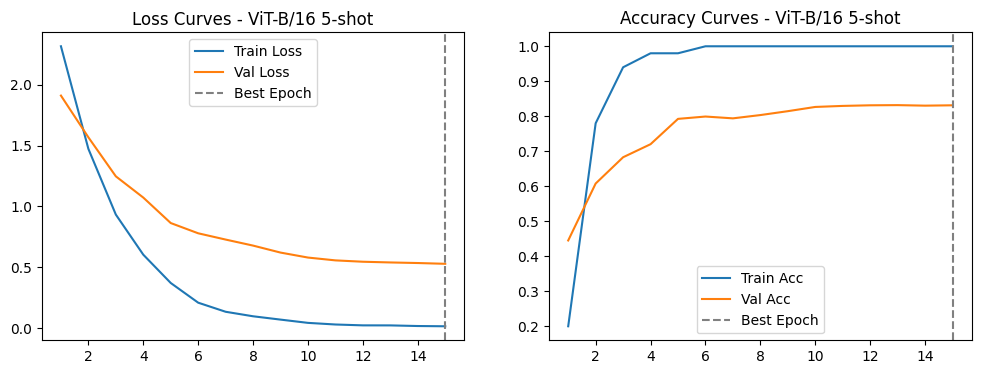

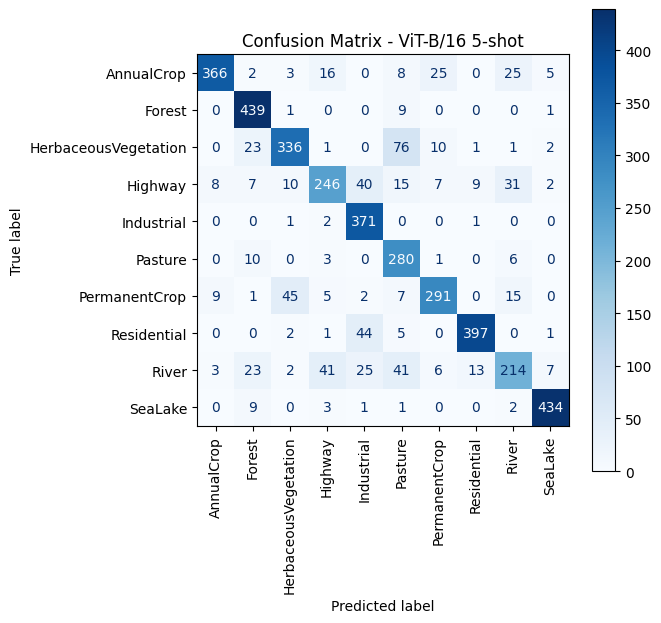

In [22]:
plot_train_curves(results_vit_5shot, "ViT-B/16 5-shot")
plot_confusion_matrix(
    results_vit_5shot["confusion_matrix"],
    class_names,
    "ViT-B/16 5-shot",
)

In [25]:
reproducibility()

efficientnetb0_10shot = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0_10shot.classifier[1].in_features
efficientnetb0_10shot.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_10shot = efficientnetb0_10shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_10shot.parameters(), 1e-3)

results_efficientnetb0_10shot = train_model(
    model=efficientnetb0_10shot,
    train_loader=train_10shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 2.2149, Train Acc: 0.2200 | Val Loss: 1.9598, Val Acc: 0.4677
Epoch 2/15 | Train Loss: 1.5333, Train Acc: 0.6200 | Val Loss: 1.5219, Val Acc: 0.5938
Epoch 3/15 | Train Loss: 1.0459, Train Acc: 0.7900 | Val Loss: 1.1423, Val Acc: 0.6669
Epoch 4/15 | Train Loss: 0.6796, Train Acc: 0.8900 | Val Loss: 0.9741, Val Acc: 0.7072
Epoch 5/15 | Train Loss: 0.5144, Train Acc: 0.8800 | Val Loss: 0.8260, Val Acc: 0.7526
Epoch 6/15 | Train Loss: 0.3569, Train Acc: 0.9100 | Val Loss: 0.7921, Val Acc: 0.7496
Epoch 7/15 | Train Loss: 0.2978, Train Acc: 0.9200 | Val Loss: 0.7719, Val Acc: 0.7546
Epoch 8/15 | Train Loss: 0.1837, Train Acc: 0.9600 | Val Loss: 0.8914, Val Acc: 0.7212
Epoch 9/15 | Train Loss: 0.2657, Train Acc: 0.9100 | Val Loss: 1.0014, Val Acc: 0.6993
Epoch 10/15 | Train Loss: 0.2387, Train Acc: 0.9300 | Val Loss: 1.0606, Val Acc: 0.6993
Early stopping triggered at epoch 10 (best val loss: 0.7719)
Test Accuracy: 74.89%
Training Time: 0.39 minu

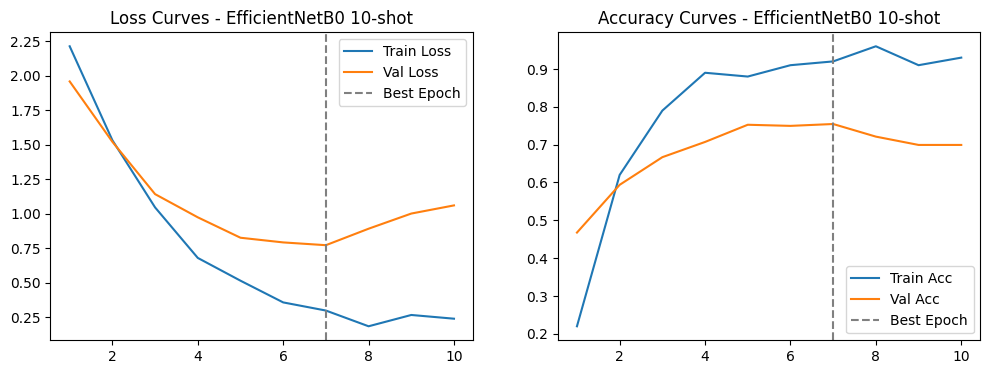

In [26]:
plot_train_curves(results_efficientnetb0_10shot, "EfficientNetB0 10-shot")

In [27]:
reproducibility()

efficientnetb0_5shot = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0_5shot.classifier[1].in_features
efficientnetb0_5shot.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_5shot = efficientnetb0_5shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_5shot.parameters(), 1e-3)

results_efficientnetb0_5shot = train_model(
    model=efficientnetb0_5shot,
    train_loader=train_5shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 2.4226, Train Acc: 0.0400 | Val Loss: 2.1732, Val Acc: 0.3183
Epoch 2/15 | Train Loss: 1.8391, Train Acc: 0.5400 | Val Loss: 1.9848, Val Acc: 0.4662
Epoch 3/15 | Train Loss: 1.3620, Train Acc: 0.7200 | Val Loss: 1.7432, Val Acc: 0.5810
Epoch 4/15 | Train Loss: 0.9699, Train Acc: 0.9000 | Val Loss: 1.4534, Val Acc: 0.6481
Epoch 5/15 | Train Loss: 0.6139, Train Acc: 1.0000 | Val Loss: 1.1705, Val Acc: 0.7040
Epoch 6/15 | Train Loss: 0.5794, Train Acc: 0.9200 | Val Loss: 0.9705, Val Acc: 0.7286
Epoch 7/15 | Train Loss: 0.2198, Train Acc: 1.0000 | Val Loss: 0.8715, Val Acc: 0.7407
Epoch 8/15 | Train Loss: 0.1733, Train Acc: 1.0000 | Val Loss: 0.8180, Val Acc: 0.7496
Epoch 9/15 | Train Loss: 0.1220, Train Acc: 1.0000 | Val Loss: 0.7848, Val Acc: 0.7548
Epoch 10/15 | Train Loss: 0.2040, Train Acc: 0.9200 | Val Loss: 0.7487, Val Acc: 0.7644
Epoch 11/15 | Train Loss: 0.0729, Train Acc: 1.0000 | Val Loss: 0.7269, Val Acc: 0.7773
Epoch 12/15 | Train

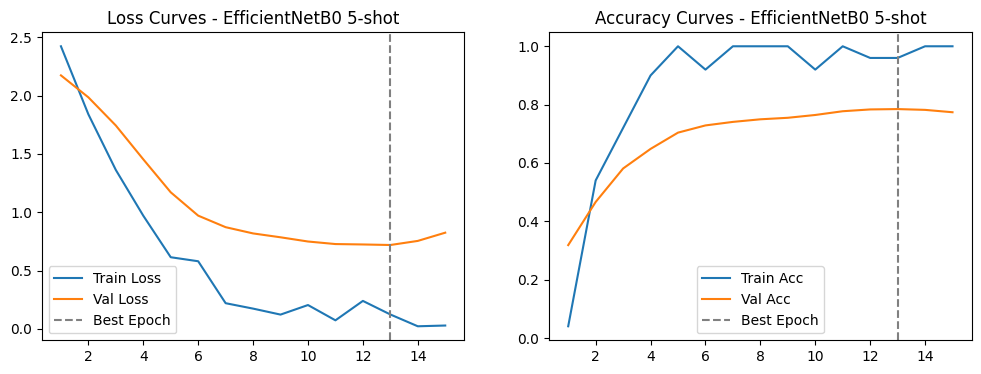

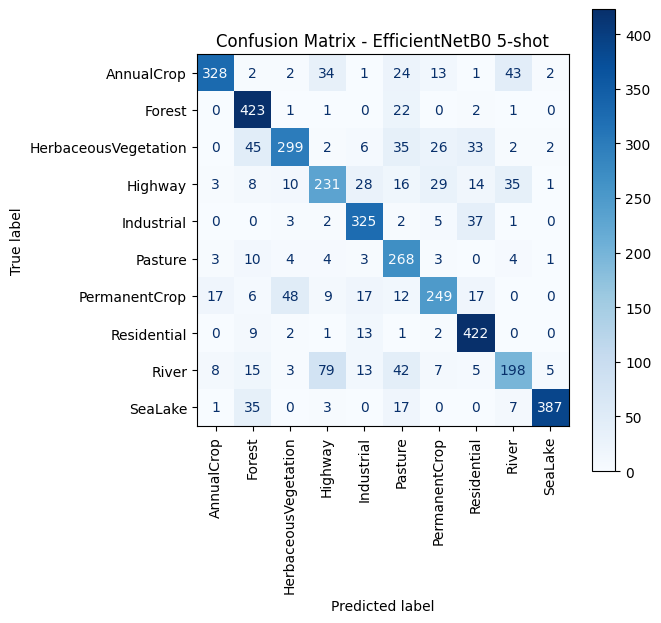

In [28]:
plot_train_curves(results_efficientnetb0_5shot, "EfficientNetB0 5-shot")
plot_confusion_matrix(
    results_efficientnetb0_5shot["confusion_matrix"],
    class_names,
    "EfficientNetB0 5-shot",
)

## 2 – Few-Shot and Zero-Shot Learning


### Task 2.1 – Prototype-based Few-Shot Classifier


In [15]:
def extract_embeddings(model, loader):
    embeddings = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feats = model(x)
            embeddings.append(feats.cpu())
            labels.append(y)

    return torch.cat(embeddings), torch.cat(labels)


def compute_prototypes(embeddings, labels, num_classes):
    prototypes = []

    for i in range(num_classes):
        class_embeddings = embeddings[labels == i]
        prototype = class_embeddings.mean(dim=0)
        prototypes.append(prototype)

    return torch.stack(prototypes)


def prototype_classify(test_embeddings, prototypes, metric="euclidean"):
    if metric == "euclidean":
        dists = torch.cdist(test_embeddings, prototypes)
        preds = dists.argmin(dim=1)
    elif metric == "cosine":
        test_norm = F.normalize(test_embeddings, dim=1)
        proto_norm = F.normalize(prototypes, dim=1)
        sims = test_norm @ proto_norm.T
        preds = sims.argmax(dim=1)
    else:
        raise ValueError("Metric must be euclidean or cosine.")

    return preds


def evaluate_few_shot(loader, test_loader, encoder, num_classes, metric="euclidean"):
    start_time = time.time()
    embeddings, labels = extract_embeddings(encoder, loader)
    test_embeddings, test_labels = extract_embeddings(encoder, test_loader)
    prototypes = compute_prototypes(embeddings, labels, num_classes)
    preds = prototype_classify(test_embeddings, prototypes, metric)
    acc = (preds == test_labels).float().mean().item()
    training_time = time.time() - start_time

    return acc, training_time

In [16]:
reproducibility()

batch_size = 16

support_10shot_loader = DataLoader(
    train_10shot, batch_size=batch_size, shuffle=False, num_workers=2
)

support_5shot_loader = DataLoader(
    train_5shot, batch_size=batch_size, shuffle=False, num_workers=2
)

test_loader_proto = DataLoader(
    test_set, batch_size=batch_size, shuffle=False, num_workers=2
)

encoder = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
encoder.fc = nn.Identity()
for param in encoder.parameters():
    param.requires_grad = False
encoder = encoder.to(device)
encoder.eval()

acc_10shot_euc, time_10shot_euc = evaluate_few_shot(
    support_10shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="euclidean",
)

acc_10shot_cos, time_10shot_cos = evaluate_few_shot(
    support_10shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="cosine",
)

acc_5shot_euc, time_5shot_euc = evaluate_few_shot(
    support_5shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="euclidean",
)

acc_5shot_cos, time_5shot_cos = evaluate_few_shot(
    support_5shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="cosine",
)

print(f"10-shot Euclidean Accuracy: {acc_10shot_euc*100:.2f}% | {time_10shot_euc / 60:.2f} minutes")
print(f"10-shot Cosine Accuracy: {acc_10shot_cos*100:.2f}% | {time_10shot_cos / 60:.2f} minutes")

print(f"5-shot Euclidean Accuracy: {acc_5shot_euc*100:.2f}% | {time_5shot_euc / 60:.2f} minutes")
print(f"5-shot Cosine Accuracy: {acc_5shot_cos*100:.2f}% | {time_5shot_cos / 60:.2f} minutes")

Random seed set to 42
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


10-shot Euclidean Accuracy: 74.25% | 0.07 minutes
10-shot Cosine Accuracy: 76.35% | 0.04 minutes
5-shot Euclidean Accuracy: 71.95% | 0.03 minutes
5-shot Cosine Accuracy: 73.58% | 0.04 minutes


### Task 2.2 – Zero-Shot Learning with CLIP


In [23]:
def clip_collate_fn(batch):
    images, labels = zip(*batch)
    return list(images), torch.tensor(labels)


test_set_clip = Subset(
    datasets.EuroSAT(root="./data", transform=None),
    test_idx,
)

batch_size_clip = 32

test_loader_clip = DataLoader(
    test_set_clip,
    batch_size=batch_size_clip,
    shuffle=False,
    collate_fn=clip_collate_fn,
)

In [24]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = clip_model.to(device)
clip_model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [25]:
basic_prompt = ["a satellite image of {}"]
domain_prompts = [
    "an aerial view of {} terrain",
    "a satellite photograph showing {} land use",
    "top-down view of {} area",
]


def encode_text(prompts):
    text_inputs = clip_processor(text=prompts, padding=True, return_tensors="pt").to(
        device
    )

    with torch.no_grad():
        text_features = clip_model.get_text_features(**text_inputs)

    text_features = F.normalize(text_features, dim=1)
    return text_features


def build_zeroshot_classifier(prompt_templates, class_names):
    all_embeddings = []

    for template in prompt_templates:
        prompts = [template.format(c) for c in class_names]
        text_emb = encode_text(prompts)
        all_embeddings.append(text_emb)

    zeroshot_weights = torch.stack(all_embeddings).mean(dim=0)
    zeroshot_weights = F.normalize(zeroshot_weights, dim=-1)

    return zeroshot_weights


def clip_zeroshot_eval(dataloader, zeroshot_weights):
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in dataloader:
            labels = labels.to(device)

            image_inputs = clip_processor(images=images, return_tensors="pt").to(device)
            image_inputs.to(device)

            image_features = clip_model.get_image_features(**image_inputs)
            image_features = F.normalize(image_features, dim=-1)

            logits = image_features @ zeroshot_weights.T
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    eval_time = time.time() - start_time
    
    acc = correct / total
    return acc, eval_time, torch.cat(all_preds), torch.cat(all_labels)


def per_class_accuracy(y_true, y_pred, class_names):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accs = {}
    for i, c in enumerate(class_names):
        mask = y_true == i
        acc = (y_pred[mask] == i).mean() if mask.sum() > 0 else 0.0
        accs[c] = acc

    return accs

In [26]:
results_clip = {}

weights_basic = build_zeroshot_classifier(basic_prompt, class_names)
acc_basic, time_basic, _, _ = clip_zeroshot_eval(test_loader_clip, weights_basic)
results_clip["Basic prompt"] = [acc_basic, time_basic]

for i, p in enumerate(domain_prompts):
    weights = build_zeroshot_classifier([p], class_names)
    acc, time_d, _, _ = clip_zeroshot_eval(test_loader_clip, weights)
    results_clip[f"Domain prompt {i+1}"] = [acc, time_d]

weights_ensemble = build_zeroshot_classifier(basic_prompt + domain_prompts, class_names)
acc_ensemble, time_ensemble, preds_clip, labels_clip = clip_zeroshot_eval(
    test_loader_clip, weights_ensemble
)
results_clip["Ensemble"] = [acc_ensemble, time_ensemble]

for k, v in results_clip.items():
    print(f"{k:<20} : {v[0]*100:.2f}% | {v[1] / 60:.2f} minutes")

Basic prompt         : 39.60% | 0.32 minutes
Domain prompt 1      : 32.57% | 0.32 minutes
Domain prompt 2      : 42.57% | 0.33 minutes
Domain prompt 3      : 32.64% | 0.32 minutes
Ensemble             : 37.58% | 0.32 minutes


CLIP Zero-Shot Per-Class Accuracy (Ensemble):

Residential            : 86.89%
Industrial             : 67.20%
Highway                : 63.20%
River                  : 52.53%
Forest                 : 44.00%
PermanentCrop          : 34.13%
AnnualCrop             : 15.11%
SeaLake                : 9.56%
Pasture                : 2.67%
HerbaceousVegetation   : 0.00%


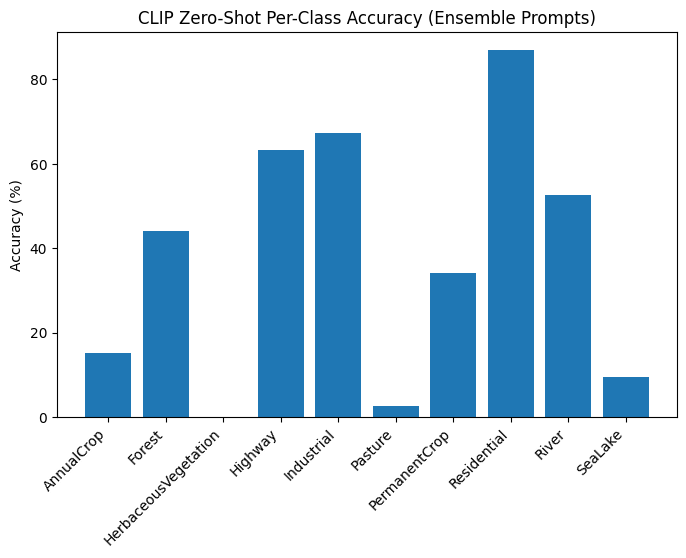

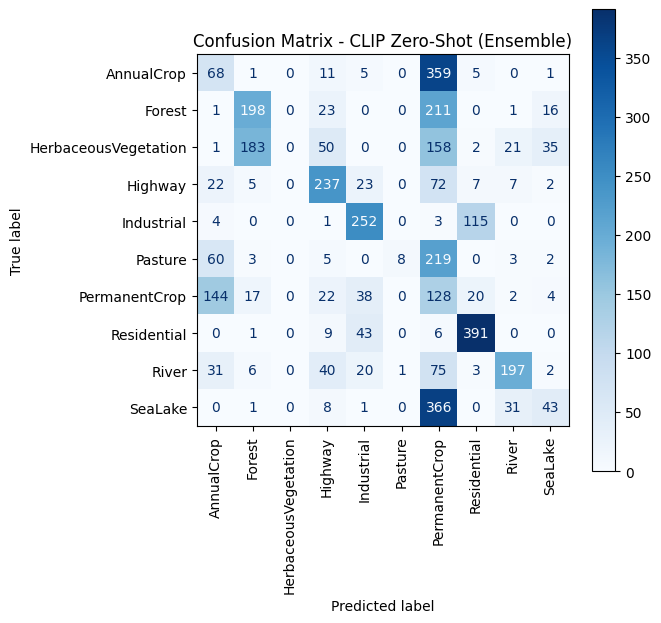

In [27]:
class_acc_clip = per_class_accuracy(
    labels_clip.numpy(), preds_clip.numpy(), class_names
)

print("CLIP Zero-Shot Per-Class Accuracy (Ensemble):\n")

for c, acc in sorted(class_acc_clip.items(), key=lambda x: x[1], reverse=True):
    print(f"{c:<22} : {acc*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(class_acc_clip.keys(), [v * 100 for v in class_acc_clip.values()])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("CLIP Zero-Shot Per-Class Accuracy (Ensemble Prompts)")
plt.show()

cm = confusion_matrix(labels_clip.numpy(), preds_clip.numpy())
plot_confusion_matrix(cm, class_names, "CLIP Zero-Shot (Ensemble)")

## 3: Self-Supervised Learning (SimCLR)


### Task 3.1 – Implementation and Evaluation SimCLR

In [12]:
transform_simclr = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.GaussianBlur(kernel_size=9),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        xi = self.transform(image)
        xj = self.transform(image)
        return xi, xj

    def __len__(self):
        return len(self.dataset)


class SimCLR(nn.Module):
    def __init__(self, backbone="resnet18", proj_dim=128):
        super().__init__()

        if backbone == "resnet18":
            encoder = models.resnet18(weights=None)
        else:
            encoder = models.resnet34(weights=None)

        self.encoder = encoder
        self.feature_dim = encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projection_head = nn.Sequential(
            nn.Linear(self.feature_dim, self.feature_dim),
            nn.ReLU(),
            nn.Linear(self.feature_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return F.normalize(z, dim=1)

In [13]:
def nt_xent_loss(z_i, z_j, temperature=0.5):
    N = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -1e9)
    pos = torch.cat([sim.diag(N), sim.diag(-N)], dim=0)
    numerator = torch.exp(pos)
    denominator = torch.sum(torch.exp(sim), dim=1)

    return -torch.log(numerator / denominator).mean()


def pretrain_simclr(model, loader, optimizer, epochs=40):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x1, x2 in loader:
            x1, x2 = x1.to(device), x2.to(device)
            z1 = model(x1)
            z2 = model(x2)
            loss = nt_xent_loss(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f}")

In [14]:
reproducibility()

eurosat_data_simclr = datasets.EuroSAT(root="./data", download=True, transform=None)

simclr_dataset = SimCLRDataset(eurosat_data_simclr, transform_simclr)

simclr_loader = DataLoader(
    simclr_dataset, batch_size=128, shuffle=True, num_workers=2
)
simclr_model = SimCLR(backbone="resnet34").to(device)

optimizer = torch.optim.Adam(simclr_model.parameters(), lr=3e-4)

pretrain_simclr(simclr_model, simclr_loader, optimizer, epochs=50)

Random seed set to 42
Epoch 1/50 | Loss: 4.5119
Epoch 2/50 | Loss: 4.2986
Epoch 3/50 | Loss: 4.1936
Epoch 4/50 | Loss: 4.1451
Epoch 5/50 | Loss: 4.1175
Epoch 6/50 | Loss: 4.1072
Epoch 7/50 | Loss: 4.0859
Epoch 8/50 | Loss: 4.0770
Epoch 9/50 | Loss: 4.0644
Epoch 10/50 | Loss: 4.0542
Epoch 11/50 | Loss: 4.0427
Epoch 12/50 | Loss: 4.0404
Epoch 13/50 | Loss: 4.0301
Epoch 14/50 | Loss: 4.0254
Epoch 15/50 | Loss: 4.0137
Epoch 16/50 | Loss: 4.0116
Epoch 17/50 | Loss: 4.0063
Epoch 18/50 | Loss: 3.9977
Epoch 19/50 | Loss: 3.9932
Epoch 20/50 | Loss: 3.9894
Epoch 21/50 | Loss: 3.9811
Epoch 22/50 | Loss: 3.9772
Epoch 23/50 | Loss: 3.9729
Epoch 24/50 | Loss: 3.9661
Epoch 25/50 | Loss: 3.9601
Epoch 26/50 | Loss: 3.9567
Epoch 27/50 | Loss: 3.9566
Epoch 28/50 | Loss: 3.9531
Epoch 29/50 | Loss: 3.9504
Epoch 30/50 | Loss: 3.9455
Epoch 31/50 | Loss: 3.9444
Epoch 32/50 | Loss: 3.9369
Epoch 33/50 | Loss: 3.9329
Epoch 34/50 | Loss: 3.9348
Epoch 35/50 | Loss: 3.9307
Epoch 36/50 | Loss: 3.9279
Epoch 37/50 | L

In [16]:
torch.save(simclr_model.state_dict(), "simclr_resnet34_pretrained(t=0.5).pth")

In [18]:
class LinearEvalModel(nn.Module):
    def __init__(self, encoder, classifier):
        super().__init__()
        self.encoder = encoder
        self.classifier = classifier

    def forward(self, x):
        feats = self.encoder(x)
        return self.classifier(feats)


reproducibility()

simclr_model1 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model1.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model1.encoder
encoder.eval()

for p in encoder.parameters():
    p.requires_grad = False

classifier = nn.Linear(512, num_classes).to(device)

linear_model = LinearEvalModel(encoder, classifier).to(device)

optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

results_linear_eval = train_model(
    model=linear_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 0.8190, Train Acc: 0.7140 | Val Loss: 0.5900, Val Acc: 0.7933
Epoch 2/30 | Train Loss: 0.7331, Train Acc: 0.7410 | Val Loss: 0.5470, Val Acc: 0.8079
Epoch 3/30 | Train Loss: 0.7263, Train Acc: 0.7446 | Val Loss: 0.5600, Val Acc: 0.8119
Epoch 4/30 | Train Loss: 0.6971, Train Acc: 0.7541 | Val Loss: 0.5374, Val Acc: 0.8054
Epoch 5/30 | Train Loss: 0.6885, Train Acc: 0.7556 | Val Loss: 0.5554, Val Acc: 0.8015
Epoch 6/30 | Train Loss: 0.6949, Train Acc: 0.7544 | Val Loss: 0.5300, Val Acc: 0.8069
Epoch 7/30 | Train Loss: 0.6843, Train Acc: 0.7623 | Val Loss: 0.5188, Val Acc: 0.8136
Epoch 8/30 | Train Loss: 0.6830, Train Acc: 0.7611 | Val Loss: 0.5433, Val Acc: 0.8067
Epoch 9/30 | Train Loss: 0.6739, Train Acc: 0.7637 | Val Loss: 0.5210, Val Acc: 0.8119
Epoch 10/30 | Train Loss: 0.6516, Train Acc: 0.7684 | Val Loss: 0.5158, Val Acc: 0.8207
Epoch 11/30 | Train Loss: 0.6614, Train Acc: 0.7677 | Val Loss: 0.5064, Val Acc: 0.8158
Epoch 12/30 | Train

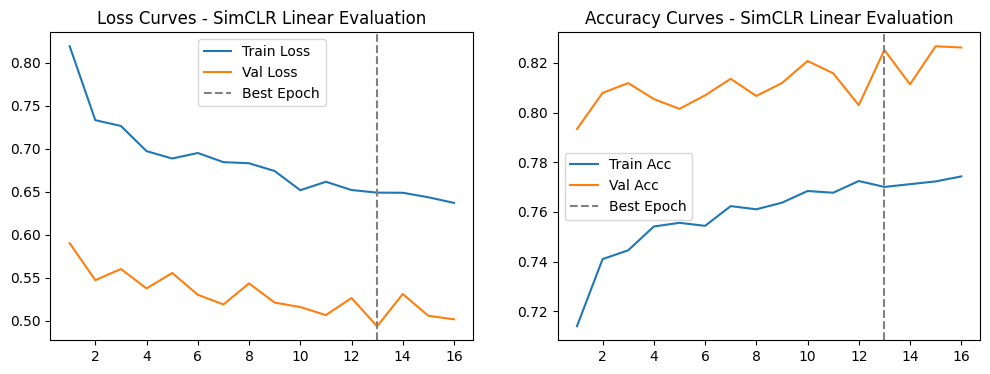

In [19]:
plot_train_curves(results_linear_eval, "SimCLR Linear Evaluation")

In [20]:
class SimCLRFinetuneModel(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        feats = self.encoder(x)
        return self.classifier(feats)


reproducibility()

simclr_model2 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model2.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model2.encoder

simclr_fine_tune = SimCLRFinetuneModel(encoder, num_classes).to(device)

optimizer = torch.optim.Adam(simclr_fine_tune.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

results_simclr_full = train_model(
    model=simclr_fine_tune,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 0.6257, Train Acc: 0.7875 | Val Loss: 0.3205, Val Acc: 0.8921
Epoch 2/30 | Train Loss: 0.3770, Train Acc: 0.8704 | Val Loss: 0.2795, Val Acc: 0.9062
Epoch 3/30 | Train Loss: 0.3144, Train Acc: 0.8916 | Val Loss: 0.2638, Val Acc: 0.9099
Epoch 4/30 | Train Loss: 0.2807, Train Acc: 0.9035 | Val Loss: 0.2418, Val Acc: 0.9170
Epoch 5/30 | Train Loss: 0.2592, Train Acc: 0.9116 | Val Loss: 0.1963, Val Acc: 0.9370
Epoch 6/30 | Train Loss: 0.2407, Train Acc: 0.9181 | Val Loss: 0.2046, Val Acc: 0.9331
Epoch 7/30 | Train Loss: 0.2251, Train Acc: 0.9221 | Val Loss: 0.1837, Val Acc: 0.9368
Epoch 8/30 | Train Loss: 0.2197, Train Acc: 0.9221 | Val Loss: 0.2079, Val Acc: 0.9316
Epoch 9/30 | Train Loss: 0.1967, Train Acc: 0.9307 | Val Loss: 0.2029, Val Acc: 0.9299
Epoch 10/30 | Train Loss: 0.1861, Train Acc: 0.9362 | Val Loss: 0.1654, Val Acc: 0.9432
Epoch 11/30 | Train Loss: 0.1823, Train Acc: 0.9374 | Val Loss: 0.2445, Val Acc: 0.9165
Epoch 12/30 | Train

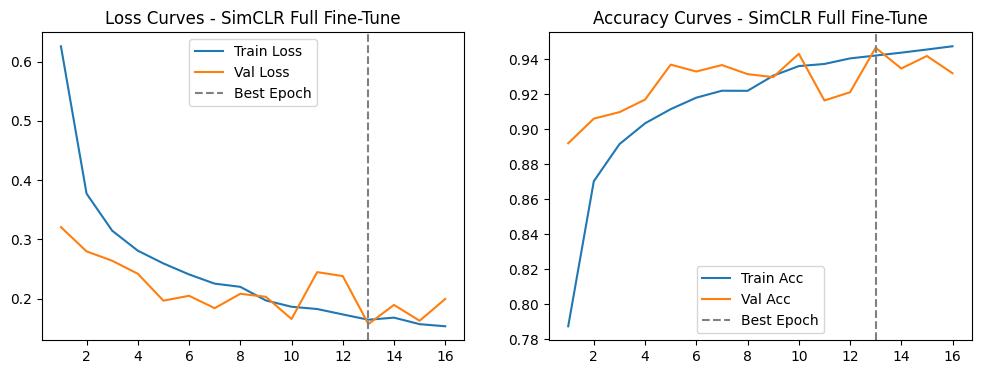

In [21]:
plot_train_curves(results_simclr_full, "SimCLR Full Fine-Tune")

In [24]:
reproducibility()

simclr_model3 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model3.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model3.encoder

simclr_fine_tune_10shot = SimCLRFinetuneModel(encoder, num_classes).to(device)

optimizer = torch.optim.Adam(simclr_fine_tune_10shot.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

results_simclr_10shot = train_model(
    model=simclr_fine_tune_10shot,
    train_loader=train_10shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 2.9568, Train Acc: 0.0700 | Val Loss: 2.8328, Val Acc: 0.0830
Epoch 2/30 | Train Loss: 2.7086, Train Acc: 0.0900 | Val Loss: 2.5941, Val Acc: 0.1240
Epoch 3/30 | Train Loss: 2.4942, Train Acc: 0.0900 | Val Loss: 2.4115, Val Acc: 0.1807
Epoch 4/30 | Train Loss: 2.2448, Train Acc: 0.1800 | Val Loss: 2.2325, Val Acc: 0.2452
Epoch 5/30 | Train Loss: 2.0138, Train Acc: 0.2900 | Val Loss: 2.1203, Val Acc: 0.3002
Epoch 6/30 | Train Loss: 1.8593, Train Acc: 0.3900 | Val Loss: 2.0164, Val Acc: 0.3333
Epoch 7/30 | Train Loss: 1.8073, Train Acc: 0.4100 | Val Loss: 1.9122, Val Acc: 0.3528
Epoch 8/30 | Train Loss: 1.6332, Train Acc: 0.5100 | Val Loss: 1.9048, Val Acc: 0.3528
Epoch 9/30 | Train Loss: 1.4640, Train Acc: 0.5700 | Val Loss: 1.7184, Val Acc: 0.4499
Epoch 10/30 | Train Loss: 1.4075, Train Acc: 0.6000 | Val Loss: 1.5926, Val Acc: 0.5163
Epoch 11/30 | Train Loss: 1.3004, Train Acc: 0.7000 | Val Loss: 1.5472, Val Acc: 0.5422
Epoch 12/30 | Train

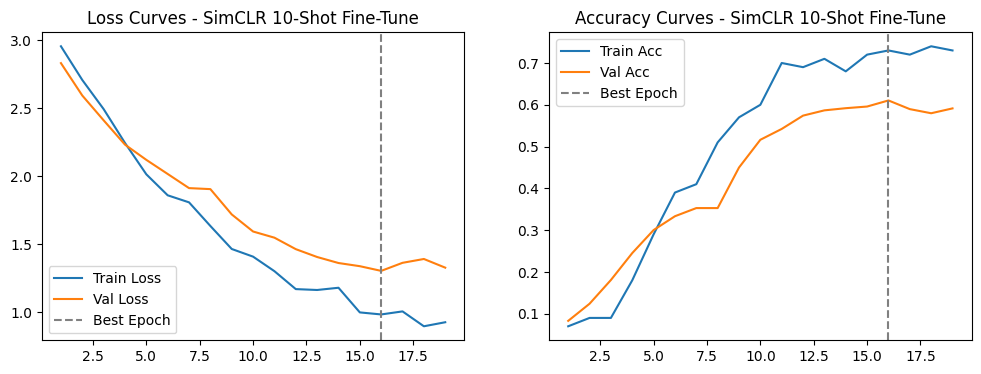

In [25]:
plot_train_curves(results_simclr_10shot, "SimCLR 10-Shot Fine-Tune")

In [26]:
reproducibility()

simclr_model4 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model4.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model4.encoder

simclr_fine_tune_5shot = SimCLRFinetuneModel(encoder, num_classes).to(device)

optimizer = torch.optim.Adam(simclr_fine_tune_5shot.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

results_simclr_5shot = train_model(
    model=simclr_fine_tune_5shot,
    train_loader=train_5shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 2.9683, Train Acc: 0.0600 | Val Loss: 2.9296, Val Acc: 0.0644
Epoch 2/30 | Train Loss: 2.7264, Train Acc: 0.0800 | Val Loss: 2.8005, Val Acc: 0.0817
Epoch 3/30 | Train Loss: 2.6136, Train Acc: 0.0400 | Val Loss: 2.6716, Val Acc: 0.1035
Epoch 4/30 | Train Loss: 2.4428, Train Acc: 0.1000 | Val Loss: 2.5517, Val Acc: 0.1402
Epoch 5/30 | Train Loss: 2.3199, Train Acc: 0.2000 | Val Loss: 2.4393, Val Acc: 0.1909
Epoch 6/30 | Train Loss: 2.1537, Train Acc: 0.3200 | Val Loss: 2.3432, Val Acc: 0.2425
Epoch 7/30 | Train Loss: 2.0971, Train Acc: 0.2000 | Val Loss: 2.2415, Val Acc: 0.2960
Epoch 8/30 | Train Loss: 1.9513, Train Acc: 0.3800 | Val Loss: 2.1546, Val Acc: 0.3353
Epoch 9/30 | Train Loss: 1.8255, Train Acc: 0.4600 | Val Loss: 2.0742, Val Acc: 0.3590
Epoch 10/30 | Train Loss: 1.7402, Train Acc: 0.4600 | Val Loss: 2.0056, Val Acc: 0.3770
Epoch 11/30 | Train Loss: 1.6182, Train Acc: 0.5400 | Val Loss: 1.9398, Val Acc: 0.3933
Epoch 12/30 | Train

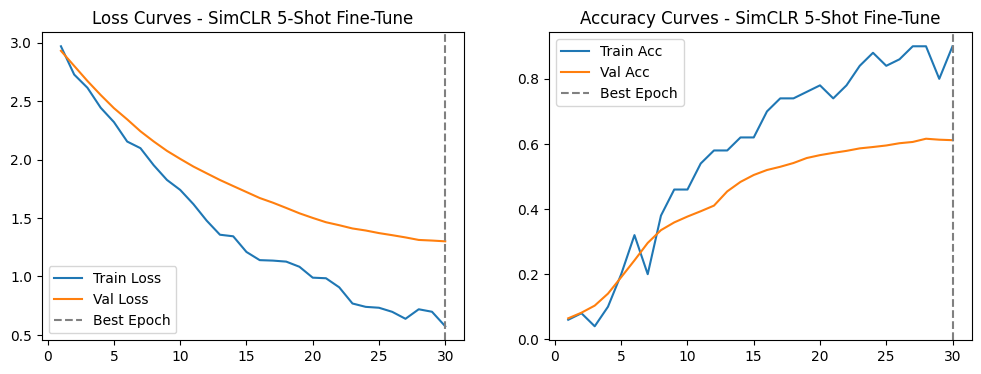

In [27]:
plot_train_curves(results_simclr_5shot, "SimCLR 5-Shot Fine-Tune")

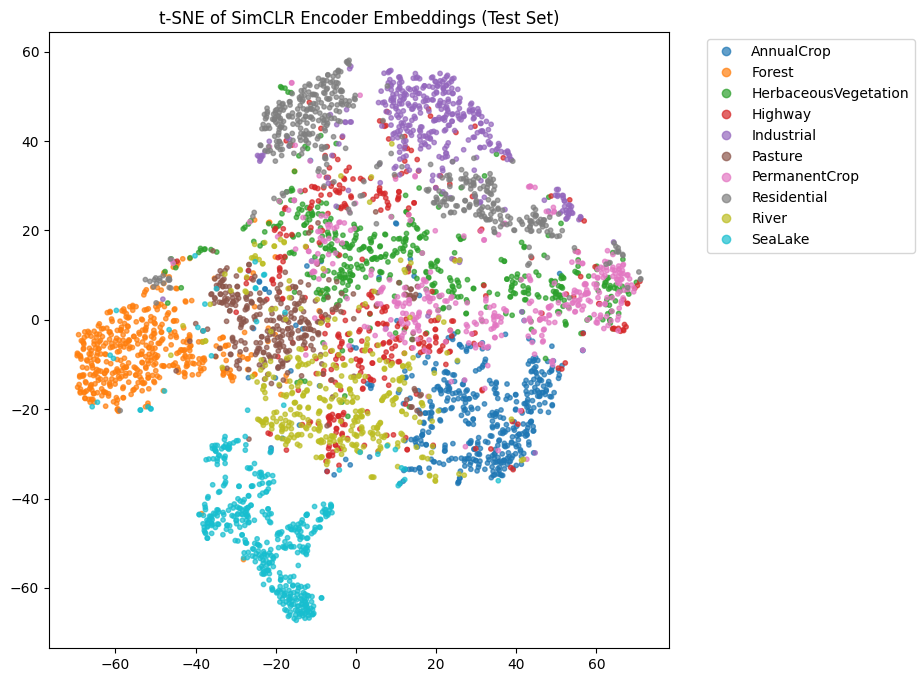

In [ ]:
def extract_embeddings(encoder, dataloader):
    encoder.eval()
    feats, labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            h = encoder(x)
            feats.append(h.cpu())
            labels.append(y)

    feats = torch.cat(feats).numpy()
    labels = torch.cat(labels).numpy()

    return feats, labels


simclr_model = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
embeddings, labels = extract_embeddings(simclr_model.encoder, test_loader)

tsne = TSNE(random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap="tab10", s=10, alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.title("t-SNE of SimCLR Encoder Embeddings (Test Set)")
plt.show()

## 4: Parameter-Efficient Fine-Tuning with LoRA

### Task 4.1 – LoRA σε Vision Transformer

In [31]:
reproducibility()

vit_lora = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
vit_lora = vit_lora.to(device)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none",
    task_type="FEATURE_EXTRACTION"
)

vit_lora = get_peft_model(vit_lora, lora_config)

vit_lora = vit_lora.to(device)

vit_lora.print_trainable_parameters()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, vit_lora.parameters()),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

results_vit_lora = train_model_vit(
    model=vit_lora,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=10
)

Random seed set to 42


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 294,912 || all params: 86,101,258 || trainable%: 0.3425
Epoch 1/10 | Train Loss: 0.8451, Train Acc: 0.7600 | Val Loss: 0.1921, Val Acc: 0.9598
Epoch 2/10 | Train Loss: 0.1394, Train Acc: 0.9637 | Val Loss: 0.1013, Val Acc: 0.9714
Epoch 3/10 | Train Loss: 0.0912, Train Acc: 0.9739 | Val Loss: 0.0780, Val Acc: 0.9758
Epoch 4/10 | Train Loss: 0.0721, Train Acc: 0.9790 | Val Loss: 0.0693, Val Acc: 0.9790
Epoch 5/10 | Train Loss: 0.0591, Train Acc: 0.9819 | Val Loss: 0.0695, Val Acc: 0.9783
Epoch 6/10 | Train Loss: 0.0529, Train Acc: 0.9838 | Val Loss: 0.0629, Val Acc: 0.9775
Epoch 7/10 | Train Loss: 0.0484, Train Acc: 0.9860 | Val Loss: 0.0644, Val Acc: 0.9793
Epoch 8/10 | Train Loss: 0.0414, Train Acc: 0.9873 | Val Loss: 0.0558, Val Acc: 0.9807
Epoch 9/10 | Train Loss: 0.0394, Train Acc: 0.9877 | Val Loss: 0.0507, Val Acc: 0.9837
Epoch 10/10 | Train Loss: 0.0354, Train Acc: 0.9889 | Val Loss: 0.0477, Val Acc: 0.9837
Test Accuracy: 98.62%
Training Time: 103.27 minutes


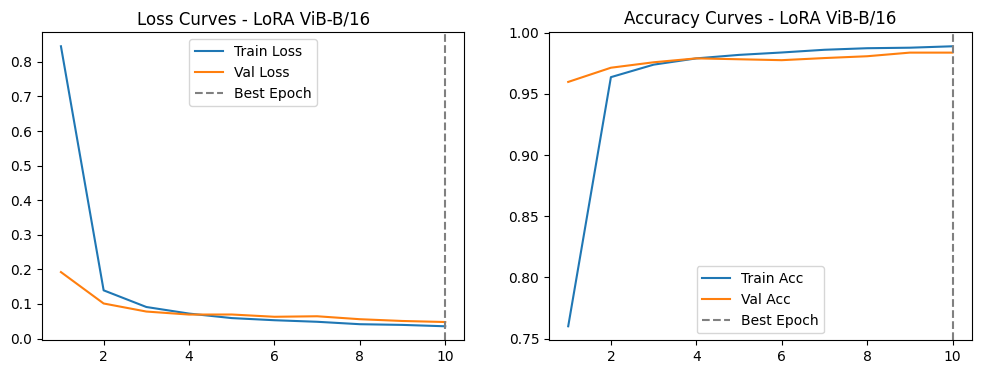

In [32]:
plot_train_curves(results_vit_lora, "LoRA ViT-B/16")